# Feature Selection


Define and implement a clear and unambiguous strategy for feature selection. Use the methods
discussed in the course. Present and justify your final selection.


Goal:
We will now start the feature selection process on the fully encoded and scaled data.
In this step, we simply load the processed datasets that were saved in the previous notebook (12_data_imputation_and_encoding.ipynb).

## Notebook Overview

This notebook performs systematic feature selection on encoded datasets. It applies filter (variance, correlation) and wrapper (RFE) methods, and prepares feature-selected outputs for modeling.

[Back to top](#top)


# Table of Contents

<a id="top"></a>

1. [Import Libraries](#sec-1-imports) <br>
2. [Load Dataset](#sec-2-load) <br>
3. [Sanity Checks and Feature Lists](#sec-3-sanity) <br>
4. [Filter Methods](#sec-4-filter) <br>
   &emsp; 4.1 [Variance Threshold (Constant/Quasi-constant)](#sec-4-1-variance) <br>
   &emsp; 4.2 [Correlation Analysis (Pearson, Spearman, Kendall)](#sec-4-2-correlation) <br>
5. [Wrapper Methods](#sec-5-wrapper) <br>
   &emsp; 5.1 [Recursive Feature Elimination (RFE)](#sec-5-1-rfe) <br>
6. [Final Insights](#sec-6-insights) <br>



<a id="sec-1-imports"></a>
## 1. Import Libraries


Load the encoded splits produced in notebook 12 and confirm shapes before proceeding.

Ensure there are no missing values in any split before running filter/wrapper methods.

Identify numeric vs. categorical features (by naming convention) to scope methods that require numeric inputs.

In [1]:
# --- Imports ---
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.base import clone



<a id="sec-2-load"></a>
## 2. Load Dataset


In [2]:

# --- Define paths ---
data_dir = "../data/"
encoded_dir = os.path.join(data_dir, "encoded_data")

# --- Load encoded & scaled datasets ---
x_train = pd.read_csv(os.path.join(encoded_dir, "12_x_train.csv"))
y_train = pd.read_csv(os.path.join(encoded_dir, "12_y_train.csv")).squeeze()

x_val = pd.read_csv(os.path.join(encoded_dir, "12_x_val.csv"))
y_val = pd.read_csv(os.path.join(encoded_dir, "12_y_val.csv")).squeeze()

x_test = pd.read_csv(os.path.join(encoded_dir, "12_x_test.csv"))

# --- Sanity checks ---
print("Encoded datasets successfully loaded!")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_val shape:   {x_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"x_test shape:  {x_test.shape}")



Encoded datasets successfully loaded!
x_train shape: (59455, 29)
y_train shape: (59455,)
x_val shape:   (15012, 29)
y_val shape:   (15012,)
x_test shape:  (32567, 29)


<a id="sec-3-sanity"></a>
## 3. Sanity Checks and Feature Lists


In [3]:
# Missing values
def has_missing(name, x):
    n = int(x.isna().sum().sum())
    print(f"[{name}] total NaNs: {n}")
    return n

_ = has_missing("x_train", x_train)
_ = has_missing("x_val",   x_val)
_ = has_missing("x_test",  x_test)


[x_train] total NaNs: 0
[x_val] total NaNs: 0
[x_test] total NaNs: 0


In [4]:
# Show feature names and the types

def show_feature_types(x):
    feature_types = {}
    for col in x.columns:
        if re.search(r'_cat$', col):
            feature_types[col] = 'categorical'
        else:
            feature_types[col] = 'numerical'
    return feature_types

feature_types = show_feature_types(x_train)
num_features = [f for f, t in feature_types.items() if t == 'numerical']
cat_features = [f for f, t in feature_types.items() if t == 'categorical']
print(f"Numerical features ({len(num_features)}): {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")

Numerical features (29): ['model', 'year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'hasDamage', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'car_age', 'mileage_per_year']
Categorical features (0): []


If any non-numeric columns persist from prior steps, drop them to keep downstream calculations consistent.

In [5]:
# Print datatypes which are not float64 or int64
print("\nFeature datatypes:")
for col in x_train.columns:
    if x_train[col].dtype not in [np.float64, np.int64]:
        print(f" - {col}: {x_train[col].dtype}")


# Drop these columns with incorrect dtypes
cols_to_drop = [col for col in x_train.columns if x_train[col].dtype not in [np.float64, np.int64]]
if cols_to_drop:
    print(f"\nDropping columns with incorrect dtypes: {cols_to_drop}")
    x_train = x_train.drop(columns=cols_to_drop)
    x_val = x_val.drop(columns=cols_to_drop)
    x_test = x_test.drop(columns=cols_to_drop)


Feature datatypes:
 - model: object

Dropping columns with incorrect dtypes: ['model']


<a id="sec-4-filter"></a>
## 4. Filter Methods


We start with Filter methods, because they are computationally inexpensive and helpful for an initial screening of features. 

<a id="sec-4-1-variance"></a>
### 4.1 Variance Threshold (Constant or Quasi-constant)


1. **Setting a Variance Threshold** - useful to deal with features that are constant or quasi-constant - thus, unlikely to be **relevant**


In [6]:
# compute population variance, round for readability, sort by variance desc

x_train.var(ddof=0).round(6).sort_values(ascending=False)


tax                       9.378906
mileage                   0.781672
mileage_per_year          0.674451
mpg                       0.672254
engineSize                0.620452
car_age                   0.506002
year                      0.506002
previousOwners            0.505396
paintQuality%             0.338518
fuelType_Petrol           0.246369
transmission_Manual       0.244088
fuelType_Diesel           0.241478
transmission_Semi-Auto    0.172585
Brand_Ford                0.169942
transmission_Automatic    0.160765
Brand_Mercedes-Benz       0.132150
Brand_Volkswagen          0.119688
Brand_Opel                0.109377
Brand_BMW                 0.089886
Brand_Audi                0.088199
Brand_Toyota              0.058271
Brand_Škoda               0.054318
Brand_Hyundai             0.042830
fuelType_Hybrid           0.028932
fuelType_Other            0.002182
transmission_Other        0.000067
fuelType_Electric         0.000050
hasDamage                 0.000000
dtype: float64

We can see that some Features have a very low variance. We will set a threshold of 0.01 to remove features with variance below this value.

In [7]:
# Function to drop low-variance features (below a given threshold)
def drop_low_variance_features(x, threshold=0.01):
    # Calculate the variance of each feature
    variances = x.var()
    # Identify features with variance below the threshold
    low_variance_features = variances[variances < threshold].index
    # Drop low-variance features
    x = x.drop(columns=low_variance_features)
    return x, low_variance_features

x_train, dropped_features = drop_low_variance_features(x_train, threshold=0.01)
x_val = x_val.drop(columns=dropped_features)
x_test = x_test.drop(columns=dropped_features)

print(f"Dropped low-variance features: {list(dropped_features)}")

Dropped low-variance features: ['hasDamage', 'transmission_Other', 'fuelType_Electric', 'fuelType_Other']


In [8]:
# Show all columns after dropping low-variance features
print(f"Remaining features after dropping low-variance features ({x_train.shape[1]}): {list(x_train.columns)}")

Remaining features after dropping low-variance features (24): ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'transmission_Automatic', 'transmission_Manual', 'transmission_Semi-Auto', 'fuelType_Diesel', 'fuelType_Hybrid', 'fuelType_Petrol', 'car_age', 'mileage_per_year']


<a id="sec-4-2-correlation"></a>
### 4.2 Correlation Analysis (Pearson, Spearman, Kendall Tau)


We have to analyze the Correlation of the features to find things about the relevance and redundancy of the features


1. Select **relevant** features - Correlation with the target (the higher the correlation in absolute value, the more relevant the feature seems to be) 
2. Exclude **redundant** features - Correlation between features (the higher the correlation in absolute value, the more redundant the feature)

For that we will use pearson for linear correlation, spearman and kendall tau for monotonic but non linear relationships and summarize our findings. We dont use Cramers V becuase we have numeric features.

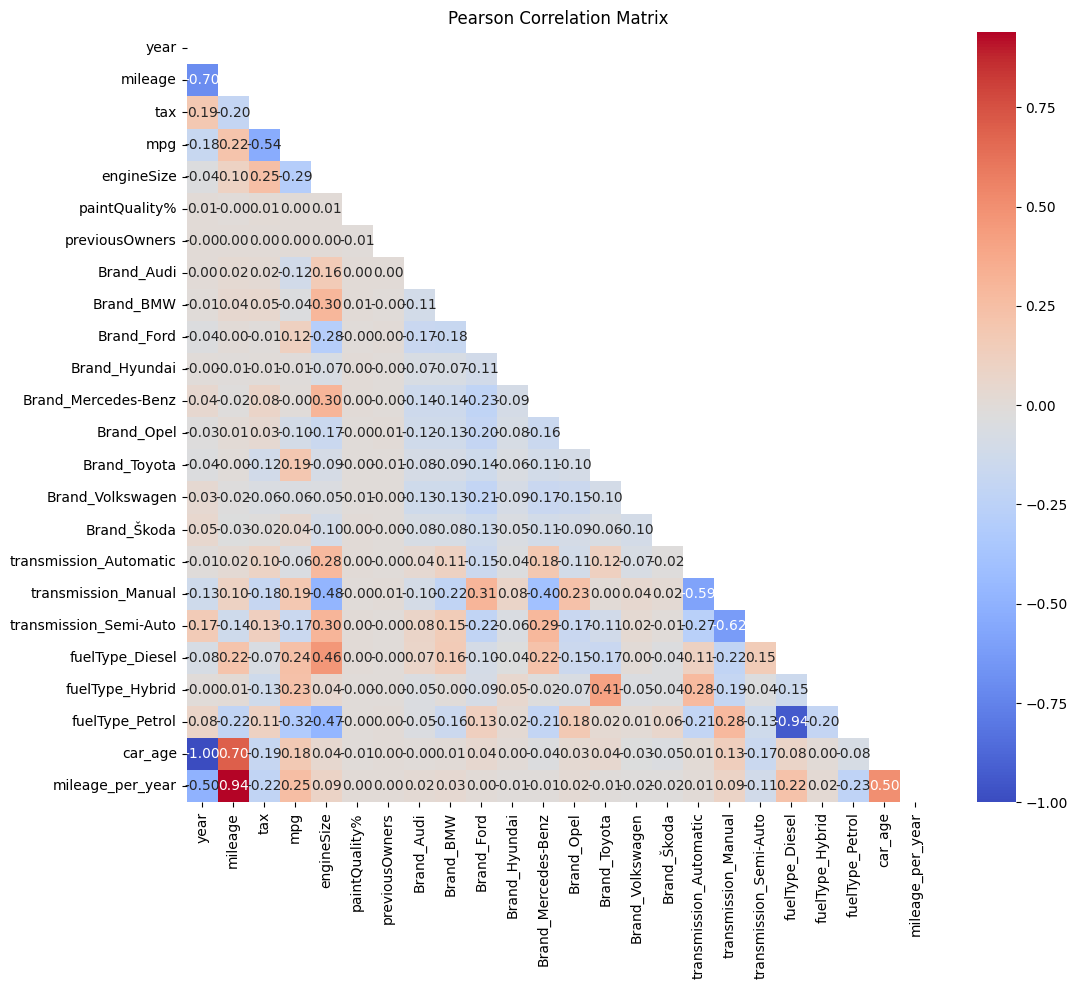

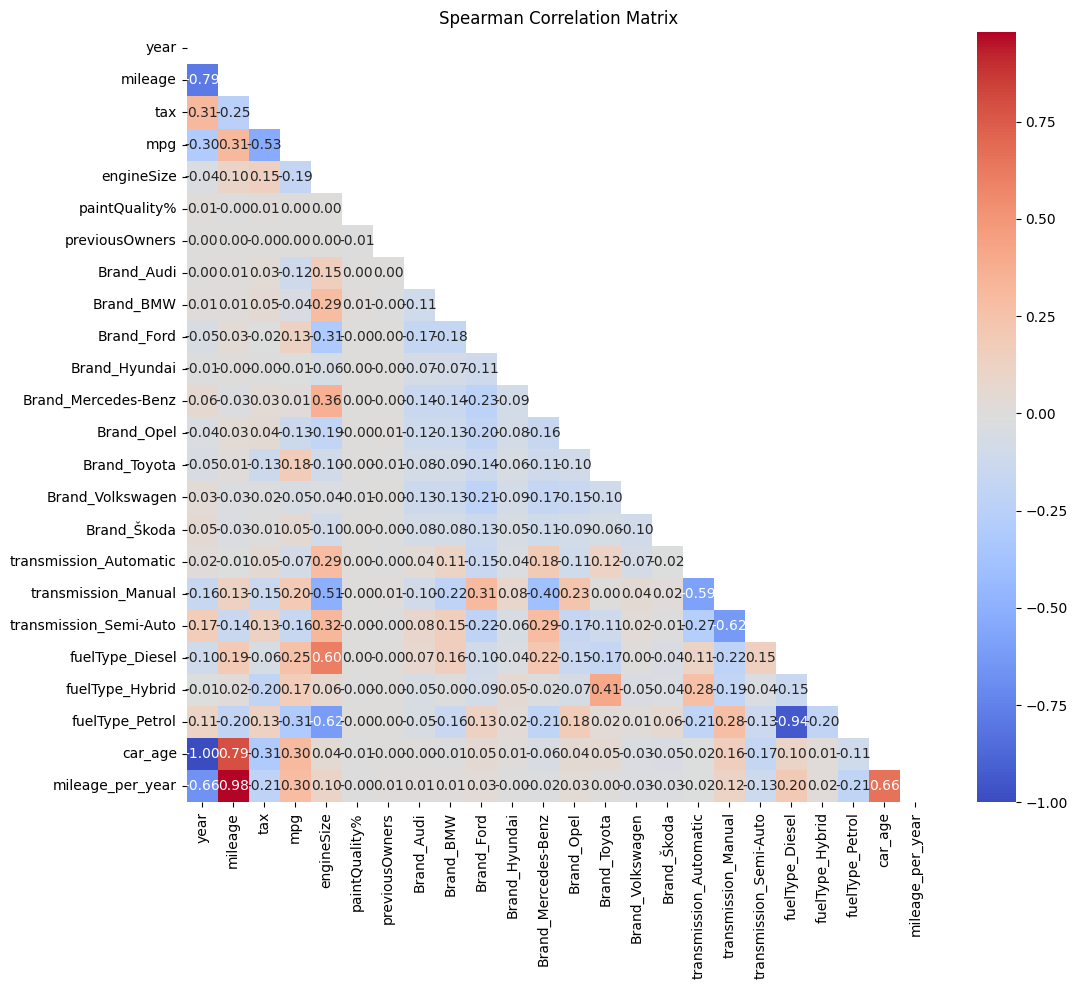

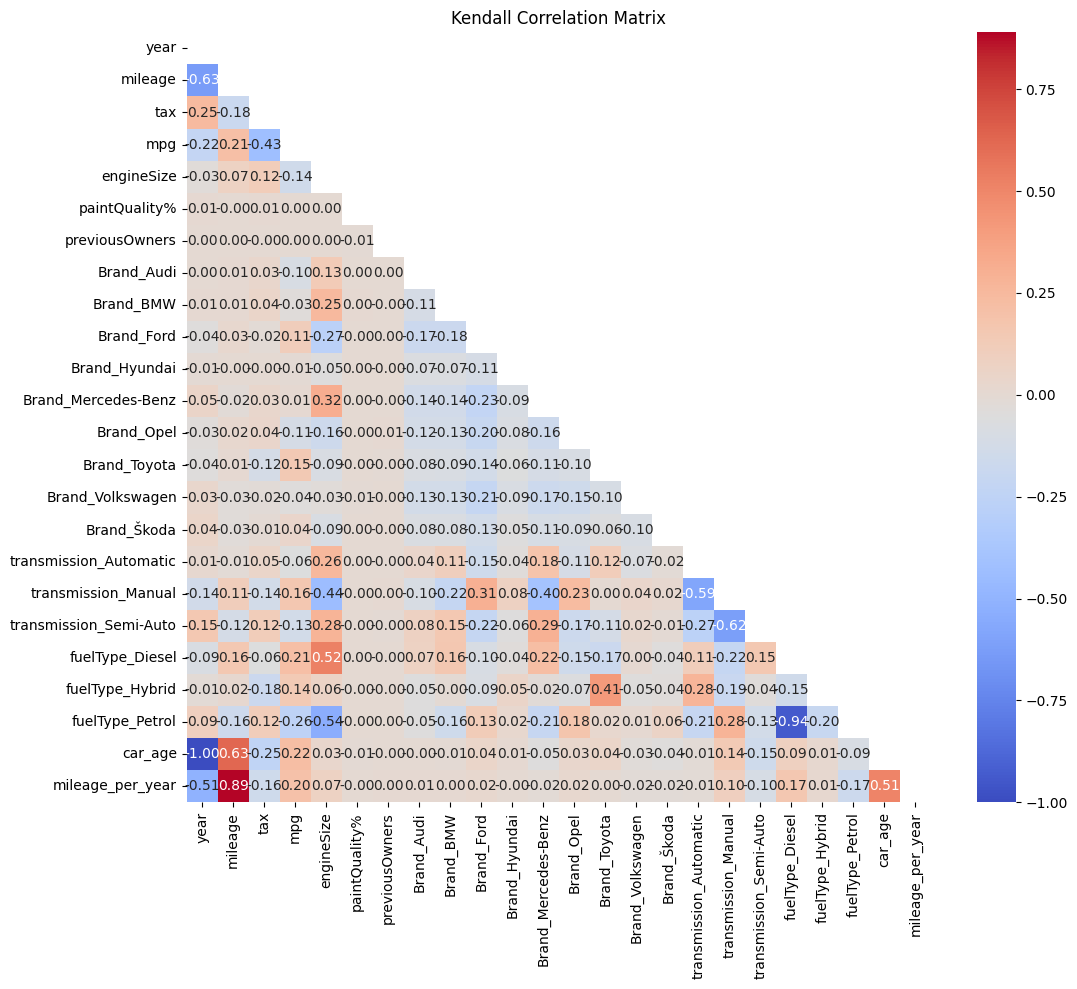

In [9]:
# Pearson, Spearman and Kendall Tau Correlation 

methods = ["pearson", "spearman", "kendall"]

for method in methods:
    cor = x_train.corr(method=method)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cor, annot=True, fmt=".2f", cmap='coolwarm', mask=np.triu(cor))
    plt.title(f'{method.capitalize()} Correlation Matrix')
    plt.show()


Summarize key correlations observed (strength, direction) and note any multicollinearity to address.

In [ ]:
# If 2 out of 3 methods show high correlation (>0.9), drop one feature from the pair
def drop_highly_correlated_features(x, threshold=0.9):
    to_drop = set()
    cor_matrices = {
        "pearson": x.corr(method="pearson"),
        "spearman": x.corr(method="spearman"),
        "kendall": x.corr(method="kendall")
    }
    
    for i in range(len(x.columns)):
        for j in range(i + 1, len(x.columns)):
            col1 = x.columns[i]
            col2 = x.columns[j]
            high_corr_count = sum(
                abs(cor_matrices[method].loc[col1, col2]) > threshold 
                for method in cor_matrices
            )
            if high_corr_count >= 2:
                to_drop.add(col2)  # Arbitrarily drop col2
    
    x = x.drop(columns=list(to_drop))
    return x, to_drop


<a id="sec-5-wrapper"></a>
## 5. Wrapper Methods


There are different types of Wrapper Methods, we will use Recursive Feature Elimination (RFE) in this case.

- Exhaustive Feature, Forward Feature Selection, Backward Feature Elimination: These methods are computationally expensive and not feasible for datasets with a large number of features.
- Recursive Feature Elimination (RFE): We will use this method because it is computationally efficient and can effectively identify the most relevant features by recursively eliminating the least important ones based on model performance.

<a id="sec-5-1-rfe"></a>
### 5.1 Recursive Feature Elimination (RFE)


We use RFE to find out the optimal number of features to select based on model performance (R² score).

In [10]:
# --- Wrapper Methods: Recursive Feature Elimination (RFE) ---
# Using different models for RFE
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.5, max_iter=5000, tol=1e-3),
    }


# --- Store results here ---
results = {}

# --- Run RFE for each model ---
nof_list = np.arange(1, len(x_train.columns) + 1)
step = max(1, len(x_train.columns)//10)

for name, base_model in models.items():
    print(f"\n===== {name} =====")
    train_scores, val_scores = [], []
    best_score = -np.inf
    best_n = 0

    for n in nof_list:
        rfe = RFE(estimator=base_model, n_features_to_select=n, step=step)
        x_train_rfe = rfe.fit_transform(x_train, y_train)
        x_val_rfe   = rfe.transform(x_val)
        model = base_model.fit(x_train_rfe, y_train)

        tr = model.score(x_train_rfe, y_train)
        va = model.score(x_val_rfe, y_val)
        train_scores.append(tr)
        val_scores.append(va)

        if va >= best_score:
            best_score = va
            best_n = n

    results[name] = {"train": train_scores, "val": val_scores, "nof": best_n}
    print(f"Best features: {best_n} | Best val score: {best_score:.4f}")



===== LinearRegression =====
Best features: 23 | Best val score: 0.7865

===== Ridge =====
Best features: 23 | Best val score: 0.7865

===== Lasso =====
Best features: 21 | Best val score: 0.7865


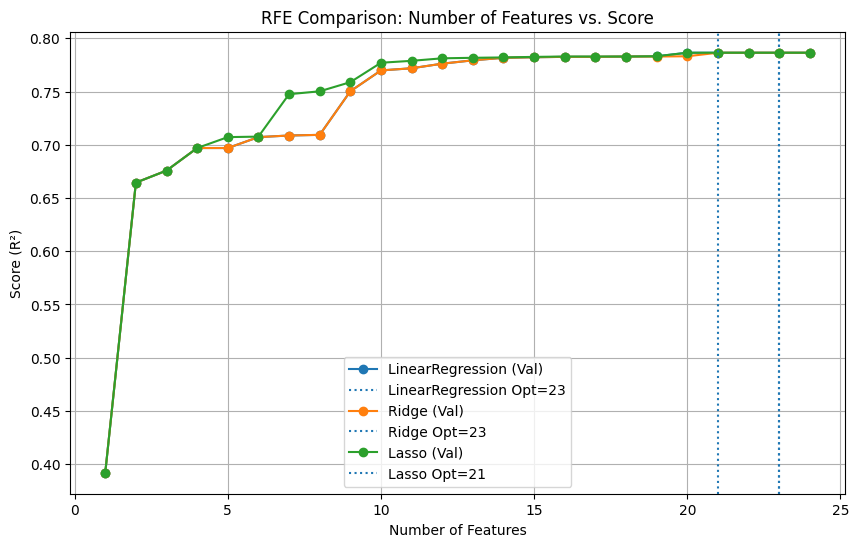

In [11]:
# --- Plot all models together ---
plt.figure(figsize=(10, 6))

for name, data in results.items():
    plt.plot(nof_list, data["val"], marker='o', label=f'{name} (Val)')
    plt.axvline(x=data["nof"], linestyle=':', label=f'{name} Opt={data["nof"]}')

plt.title("RFE Comparison: Number of Features vs. Score")
plt.xlabel("Number of Features")
plt.ylabel("Score (R²)")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Display the selected features for Linear Regression with optimal number of features
model = LinearRegression()
nof = results["LinearRegression"]["nof"]

rfe = RFE(estimator=model, n_features_to_select=nof)
X_rfe = rfe.fit_transform(x_train, y_train)
selected_features = x_train.columns[rfe.support_]
print("Selected features:")
for feature in selected_features:
    print(f" - {feature}")

plt.show()

Selected features:
 - year
 - mileage
 - tax
 - mpg
 - engineSize
 - paintQuality%
 - Brand_Audi
 - Brand_BMW
 - Brand_Ford
 - Brand_Hyundai
 - Brand_Mercedes-Benz
 - Brand_Opel
 - Brand_Toyota
 - Brand_Volkswagen
 - Brand_Škoda
 - transmission_Automatic
 - transmission_Manual
 - transmission_Semi-Auto
 - fuelType_Diesel
 - fuelType_Hybrid
 - fuelType_Petrol
 - car_age
 - mileage_per_year


In [13]:
# Create subset for x_train and y_train for better performance during feature selection
x_train_subset = x_train.sample(n=1000, random_state=42)
y_train_subset = y_train.loc[x_train_subset.index] 
x_val_subset = x_val.sample(n=200, random_state=42)
y_val_subset = y_val.loc[x_val_subset.index]

In [14]:
#no of features
nof_list=np.arange(1,len(x_train_subset.columns)+1)            
high_score=0
best_feature_names = None  
#Variable to store the optimum features
nof=0           
train_score_list =[]
val_score_list = []

for n in range(len(nof_list)):
    model = RandomForestRegressor()

    rfe = RFE(estimator=model, n_features_to_select=nof_list[n])
    x_train_rfe = rfe.fit_transform(x_train_subset, y_train_subset)
    x_val_rfe = rfe.transform(x_val_subset)
    model.fit(x_train_rfe, y_train_subset)

    #storing results on training data
    train_score = model.score(x_train_rfe, y_train_subset)
    train_score_list.append(train_score)
    
    #storing results on validation data
    val_score = model.score(x_val_rfe, y_val_subset)
    val_score_list.append(val_score)
    
    #check best score
    if(val_score >= high_score):
        high_score = val_score
        nof = nof_list[n]
        # store current best feature names
        best_feature_names = x_train_subset.columns[rfe.support_].tolist()

print("Optimum number of features: %d" %nof)
print("Score with %d features: %f" % (nof, high_score))
print("Selected features:")
for feature in best_feature_names:
    print(f" - {feature}")


Optimum number of features: 22
Score with 22 features: 0.821459
Selected features:
 - year
 - mileage
 - tax
 - mpg
 - engineSize
 - paintQuality%
 - previousOwners
 - Brand_Audi
 - Brand_BMW
 - Brand_Ford
 - Brand_Mercedes-Benz
 - Brand_Opel
 - Brand_Volkswagen
 - Brand_Škoda
 - transmission_Automatic
 - transmission_Manual
 - transmission_Semi-Auto
 - fuelType_Diesel
 - fuelType_Hybrid
 - fuelType_Petrol
 - car_age
 - mileage_per_year


We select the Features which have the best performance according to RFE with Random Forest Regressor.

In [15]:
# We select the features (best_feature_names) from random forest results, because it gave the best performance

x_train = x_train[best_feature_names]
x_val = x_val[best_feature_names]
x_test = x_test[best_feature_names]

Export the feature-selected datasets for downstream modeling (notebook 30).

In [16]:
# Print number of columns of the new datasets
print(f"x_train shape after feature selection: {x_train.shape}")
print(f"x_val shape after feature selection:   {x_val.shape}")
print(f"x_test shape after feature selection:  {x_test.shape}")

x_train shape after feature selection: (59455, 22)
x_val shape after feature selection:   (15012, 22)
x_test shape after feature selection:  (32567, 22)


In [17]:
# Export the dataset with selected features only
x_train = x_train[best_feature_names]
x_val = x_val[best_feature_names]
x_test = x_test[best_feature_names]

# --- Save feature selected datasets ---
output_dir = os.path.join(data_dir, "feature_selection")
os.makedirs(output_dir, exist_ok=True)
x_train.to_csv(os.path.join(output_dir, "20_x_train.csv"), index=False)
y_train.to_csv(os.path.join(output_dir, "20_y_train.csv"), index=False)
x_val.to_csv(os.path.join(output_dir, "20_x_val.csv"), index=False)
y_val.to_csv(os.path.join(output_dir, "20_y_val.csv"), index=False)
x_test.to_csv(os.path.join(output_dir, "20_x_test.csv"), index=False)

print ("Feature selected data saved successfully (x/y separated):")

Feature selected data saved successfully (x/y separated):


### Next Steps
In the next notebook, we will proceed to modeling and evaluation using the feature-selected datasets prepared here.

[Back to top](#top)
